# Testing the Final model

In [24]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pickle
import os

In [25]:
prediction_model = tf.keras.models.load_model(
    "captcha_reader.keras"
)

print("Model is loaded")

Model is loaded


In [26]:
with open(
    "char_mapping.pkl",
    "rb"
) as f:

    mappings = pickle.load(f)

char_to_num = mappings["char_to_num"]
num_to_char = mappings["num_to_char"]

print("Mappings Loaded")

Mappings Loaded


In [27]:
def preprocess_image(path):

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    img = img.astype(np.float32)

    img = img / 255.0

    img = np.expand_dims(
        img,
        axis=-1
    )

    return img

In [28]:
BLANK_TOKEN = 31


def decode_prediction(pred):

    decoded_raw = np.argmax(
        pred,
        axis=-1
    )

    decoded_ctc = []

    prev = -1

    for x in decoded_raw:

        if x != prev:
            decoded_ctc.append(x)

        prev = x

    decoded_ctc = [
        x
        for x in decoded_ctc
        if x != BLANK_TOKEN
    ]

    return decoded_ctc

In [29]:
def indices_to_text(indices):

    return "".join(
        num_to_char[int(x)]
        for x in indices
    )

In [30]:
def predict_captcha(path):

    img = preprocess_image(path)

    pred = prediction_model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    decoded = decode_prediction(
        pred[0]
    )

    text = indices_to_text(
        decoded
    )

    plt.imshow(
        img.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Prediction: {text}",
        color="purple"
    )

    plt.axis("off")
    plt.show()

    return text

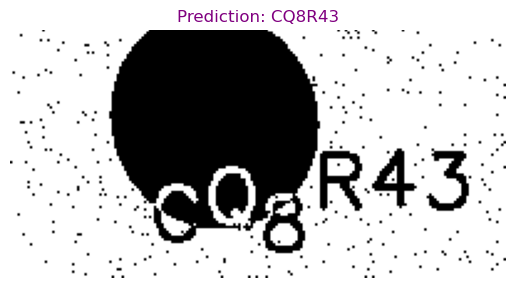

'CQ8R43'

In [31]:
predict_captcha(r"C:\Users\ronak\OneDrive - iitr.ac.in\Desktop\CIG Captcha Reader\cig_ps\test_images\test-267.png")
 # Trying random test images to check using the above function

In [32]:
import pandas as pd
import os

In [33]:
test_folder = r"C:\Users\ronak\OneDrive - iitr.ac.in\Desktop\CIG Captcha Reader\cig_ps\test_images"


In [34]:
def predict_text(path):

    img = preprocess_image(path)

    pred = prediction_model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    decoded = decode_prediction(
        pred[0]
    )

    return indices_to_text(decoded)  #Doesnt call matplot to generarte 5000 images lol

In [35]:
images = []
filenames = []
files = sorted(
    os.listdir(test_folder),
    key=lambda x: int(
        x.replace("test-", "")
         .replace(".png", "")
    )
)
for file in files:

    path = os.path.join(
        test_folder,
        file
    )

    img = preprocess_image(path)

    images.append(img)
    filenames.append(file)

images = np.array(images)

print(images.shape)

(5000, 100, 200, 1)


In [36]:
preds = prediction_model.predict(
    images,
    batch_size=64,
    verbose=1
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step


In [37]:
results = []

for i in range(len(filenames)):

    decoded = decode_prediction(
        preds[i]
    )

    text = indices_to_text(
        decoded
    )

    results.append(
        {
            "image": filenames[i],
            "text": text
        }
    )

In [38]:
submission = pd.DataFrame(
    results
)

In [39]:
submission.tail()

,image,text
4995,test-4995.png,R5ENAF
4996,test-4996.png,WNQH33
4997,test-4997.png,9SYANQ
4998,test-4998.png,9X7DDR
4999,test-4999.png,Z2WTZ3


# Submission FILE 

In [18]:
submission.to_csv(
    "submission.csv",
    index=False
)
